# Análise Exploratória de Dados — Dataset DUAT

Este notebook faz a **análise exploratória (EDA)** do dataset normalizado do projeto DUAT (`dataset-duat-normalizado_float32.csv`), comparando as 20 features numéricas extraídas das notícias entre as classes **Fake News (0)** e **Notícia Verdadeira (1)**.



## 0. Instalação das dependências



In [1]:
%pip install -q pandas matplotlib seaborn


## 1. Setup — imports, carregamento do dataset e definição das colunas

O que esta célula faz:
- Importa as bibliotecas usadas no notebook: `math` (cálculo de grades de subplots), `pandas` (manipulação de dados), `matplotlib`/`seaborn` (visualização).
- Carrega o dataset normalizado (`dataset-duat-normalizado_float32.csv`) em `df`.
- Cria a coluna auxiliar `tipo_noticia`, traduzindo o rótulo binário (`rotulo`: 0/1) para os textos usados como legenda nos gráficos (`"Fake News (0)"` / `"Notícia Verdadeira (1)"`).
- Define `colunas_numericas`: a lista das 20 features numéricas do dataset que serão comparadas entre as duas classes ao longo do notebook (léxicas, sintáticas, estilísticas e de legibilidade).


In [2]:
# Inicializando Imports, Dataset, Colunas

import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


dataset = 'dataset-duat-normalizado_float32.csv'


df = pd.read_csv(dataset)
df['tipo_noticia'] = df['rotulo'].map({0: 'Fake News (0)', 1: 'Notícia Verdadeira (1)'})

colunas_numericas = [
    "diversidade_lexica",
    "tamanho_medio_palavra",
    "num_tokens",
    "num_palavras",
    "pct_erro_ortografico",
    "types_proporcao",
    "fontes_proporcao",
    "estudos_previos_proporcao",
    "emotividade",
    "sensacionalismo_proporcao",
    "verbos_proporcao",
    "verbos_subj_imp_proporcao",
    "substantivos_proporcao",
    "adjetivos_proporcao",
    "adverbios_proporcao",
    "modais_proporcao",
    "pronomes_proporcao",
    "pausalidade",
    "indice_legibilidade",
    "tamanho_medio_frase",
]


## 2. Gráfico 1 — Média de cada feature por classe (barras)

O que esta célula faz:
- Monta uma grade de subplots (4 colunas × linhas calculadas dinamicamente com `math.ceil`) — um subplot por feature.
- Para cada feature em `colunas_numericas`, calcula a **média** agrupada por `tipo_noticia` (`groupby(...).mean()`) e plota como gráfico de barras, comparando Fake News vs. Notícia Verdadeira.
- Remove eixos vazios da grade que sobrarem sem gráfico (`fig.delaxes`) — hoje não sobra nenhum, pois 20 features preenchem exatamente a grade 5×4.
- Salva a figura em `matriz_graficos.png`.

Grid created successfully


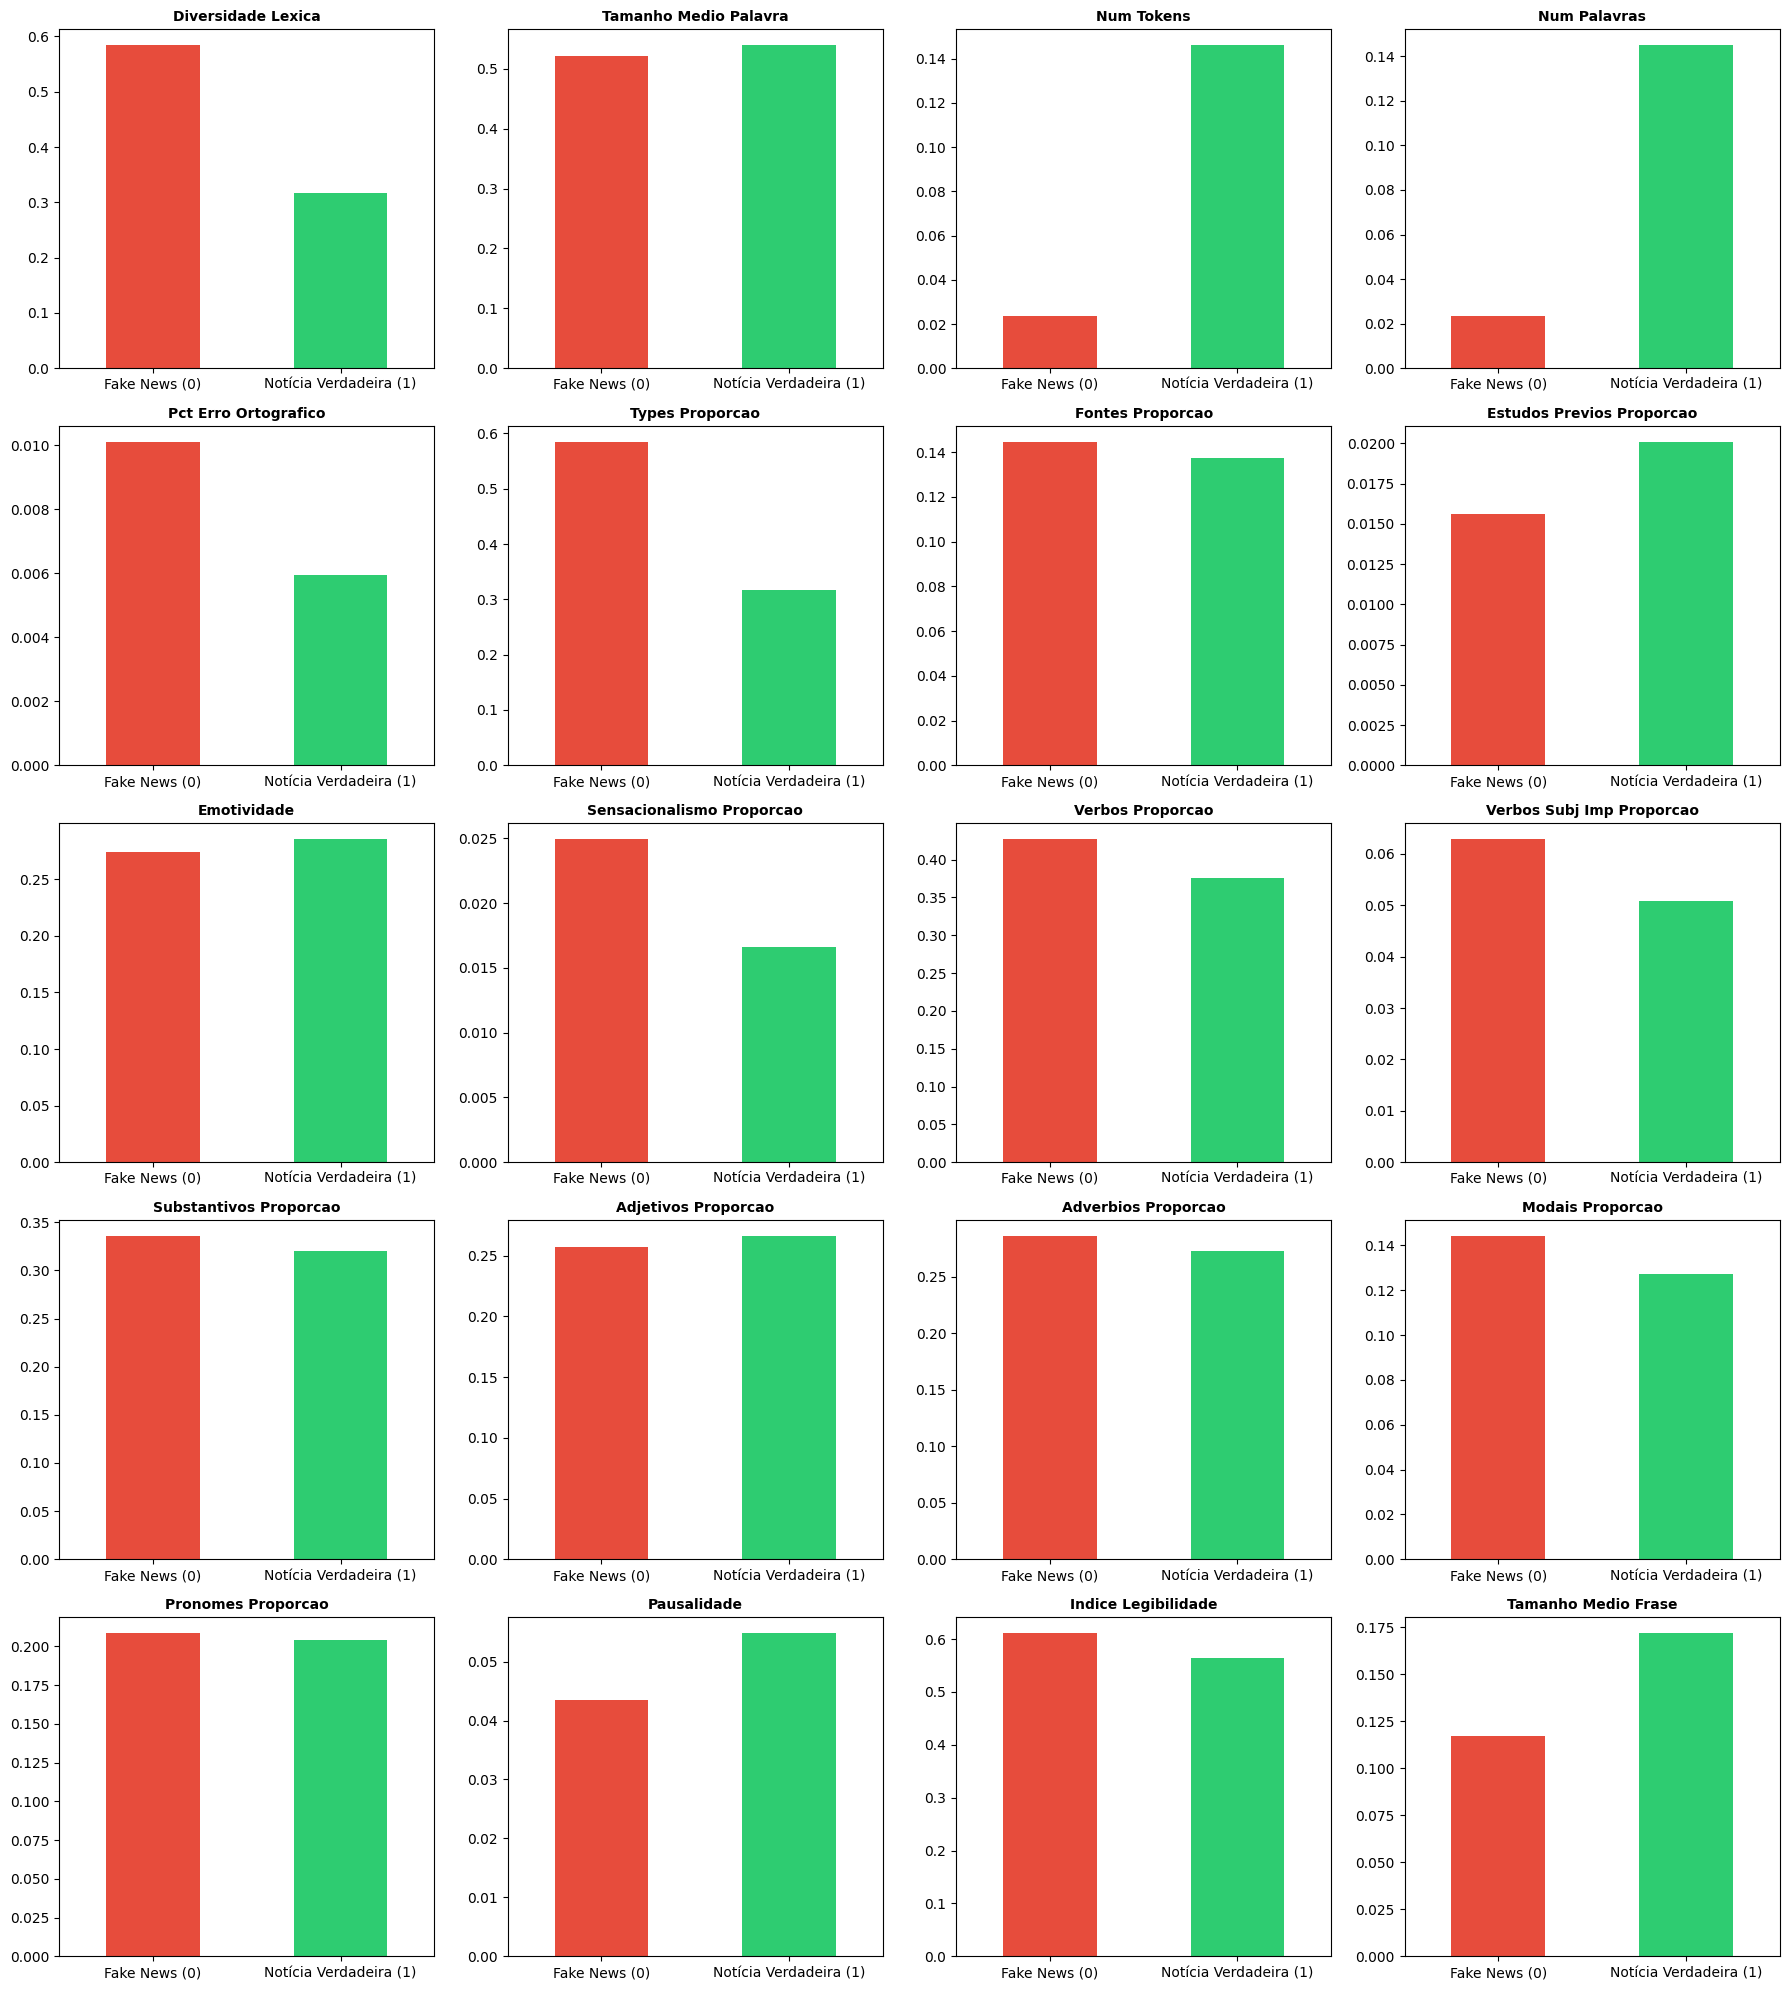

In [3]:
#Gráfico 1: Média da variável
n_cols = 4
n_rows = math.ceil(len(colunas_numericas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 20))

idx = 0
for i in range(n_rows):
    for j in range(n_cols):
        if idx < len(colunas_numericas):
            var = colunas_numericas[idx]
            df.groupby('tipo_noticia')[var].mean().plot(
                kind='bar', ax=axes[i, j], color=['#e74c3c', '#2ecc71'], rot=0
            )
            axes[i, j].set_title(var.replace("_", " ").title(), fontsize=10, fontweight='bold')
            axes[i, j].set_xlabel('')
            idx += 1
        else:
            fig.delaxes(axes[i, j]) # Remove eixos vazios

plt.tight_layout()
plt.savefig('matriz_graficos.png')
print("Grid created successfully")


## 3. Gráfico 2 — Comparação de pares de features consecutivas (barras duplas)

O que esta célula faz:
- Agrupa as 20 features em 10 pares consecutivos (`(diversidade_lexica, tamanho_medio_palavra)`, `(num_tokens, num_palavras)`, etc.), na ordem em que aparecem em `colunas_numericas`.
- Para cada par, calcula a média das duas features por `tipo_noticia` e monta um `DataFrame` com esses valores, plotando as duas como barras lado a lado no mesmo subplot — facilita comparar a escala relativa de duas métricas próximas ao mesmo tempo.
- Usa `sns.set_theme(style="whitegrid")` para o estilo visual dos gráficos seguintes também (o tema do seaborn é global até ser trocado de novo).

Como os pares seguem apenas a ordem da lista (e não uma relação temática entre as features), o valor desta célula é mais de visualização compacta do que de comparação conceitual — vale ter isso em mente ao interpretar os pares.

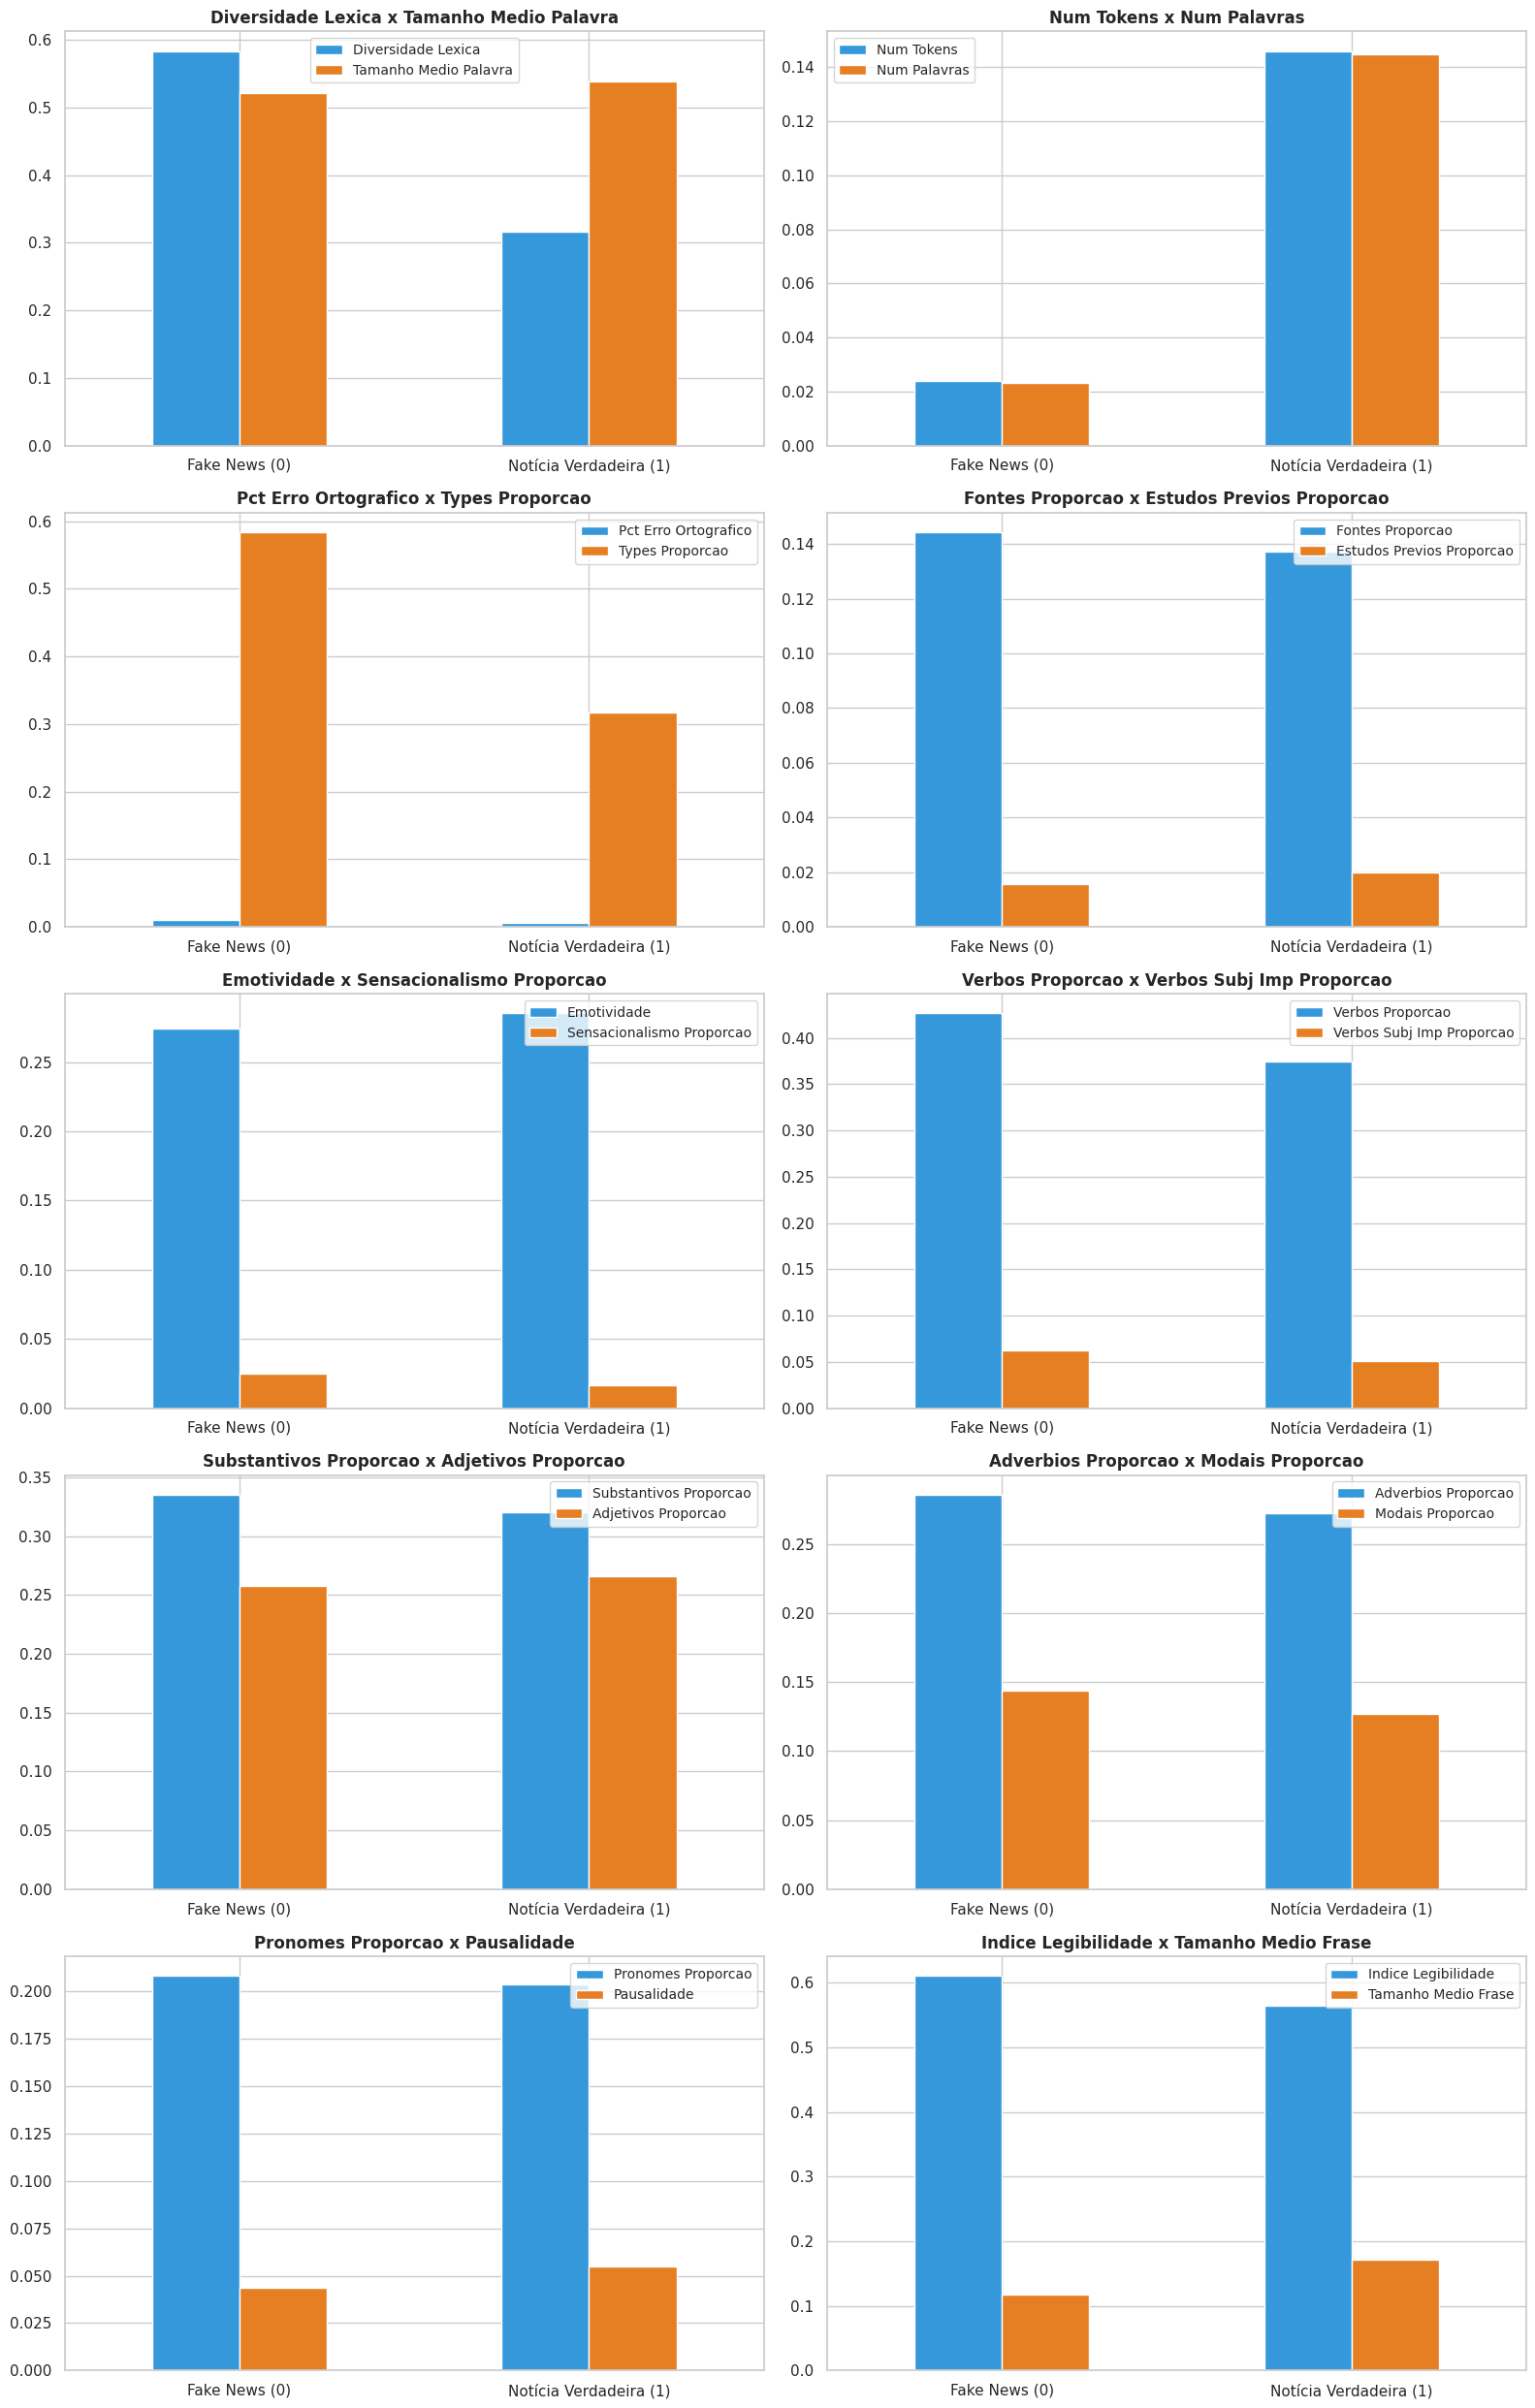

In [4]:
# Gráfico 2: Duas variáveis lado a lado por gráfico
pares_metricas = [
    (
        colunas_numericas[i],
        colunas_numericas[i + 1],
        f"{colunas_numericas[i].replace('_', ' ').title()} x {colunas_numericas[i + 1].replace('_', ' ').title()}",
    )
    for i in range(0, len(colunas_numericas) - 1, 2)
]

# Configuração da grade: 2 células por linha com altura/largura ampliadas
n_cols = 2
n_rows = math.ceil(len(pares_metricas) / n_cols)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

idx = 0
for i in range(n_rows):
    for j in range(n_cols):
        if idx < len(pares_metricas):
            var1, var2, titulo = pares_metricas[idx]

            # Construção do DataFrame agrupado (estilo Gráfico 2)
            data_grafico = pd.DataFrame({
                var1.replace("_", " ").title(): df.groupby('tipo_noticia')[var1].mean(),
                var2.replace("_", " ").title(): df.groupby('tipo_noticia')[var2].mean()
            })

            # Plotagem em barras duplas comparativas
            data_grafico.plot(kind='bar', ax=axes[i, j], color=['#3498db', '#e67e22'], rot=0)

            axes[i, j].set_title(titulo, fontsize=12, fontweight='bold')

            axes[i, j].set_xlabel('')
            axes[i, j].legend(fontsize=10)

            idx += 1
        else:
            fig.delaxes(axes[i, j])

plt.tight_layout()
plt.show()


## 4. Gráfico 3 — Violin plots (distribuição + quartis por classe)

O que esta célula faz:
- Para cada feature, plota um **violin plot** (`sns.violinplot`) separado por `tipo_noticia`, mostrando a forma completa da distribuição (não só a média) e os quartis (`inner='quartile'`).
- É o gráfico mais informativo para identificar **outliers por critério** e diferenças de dispersão entre as classes.

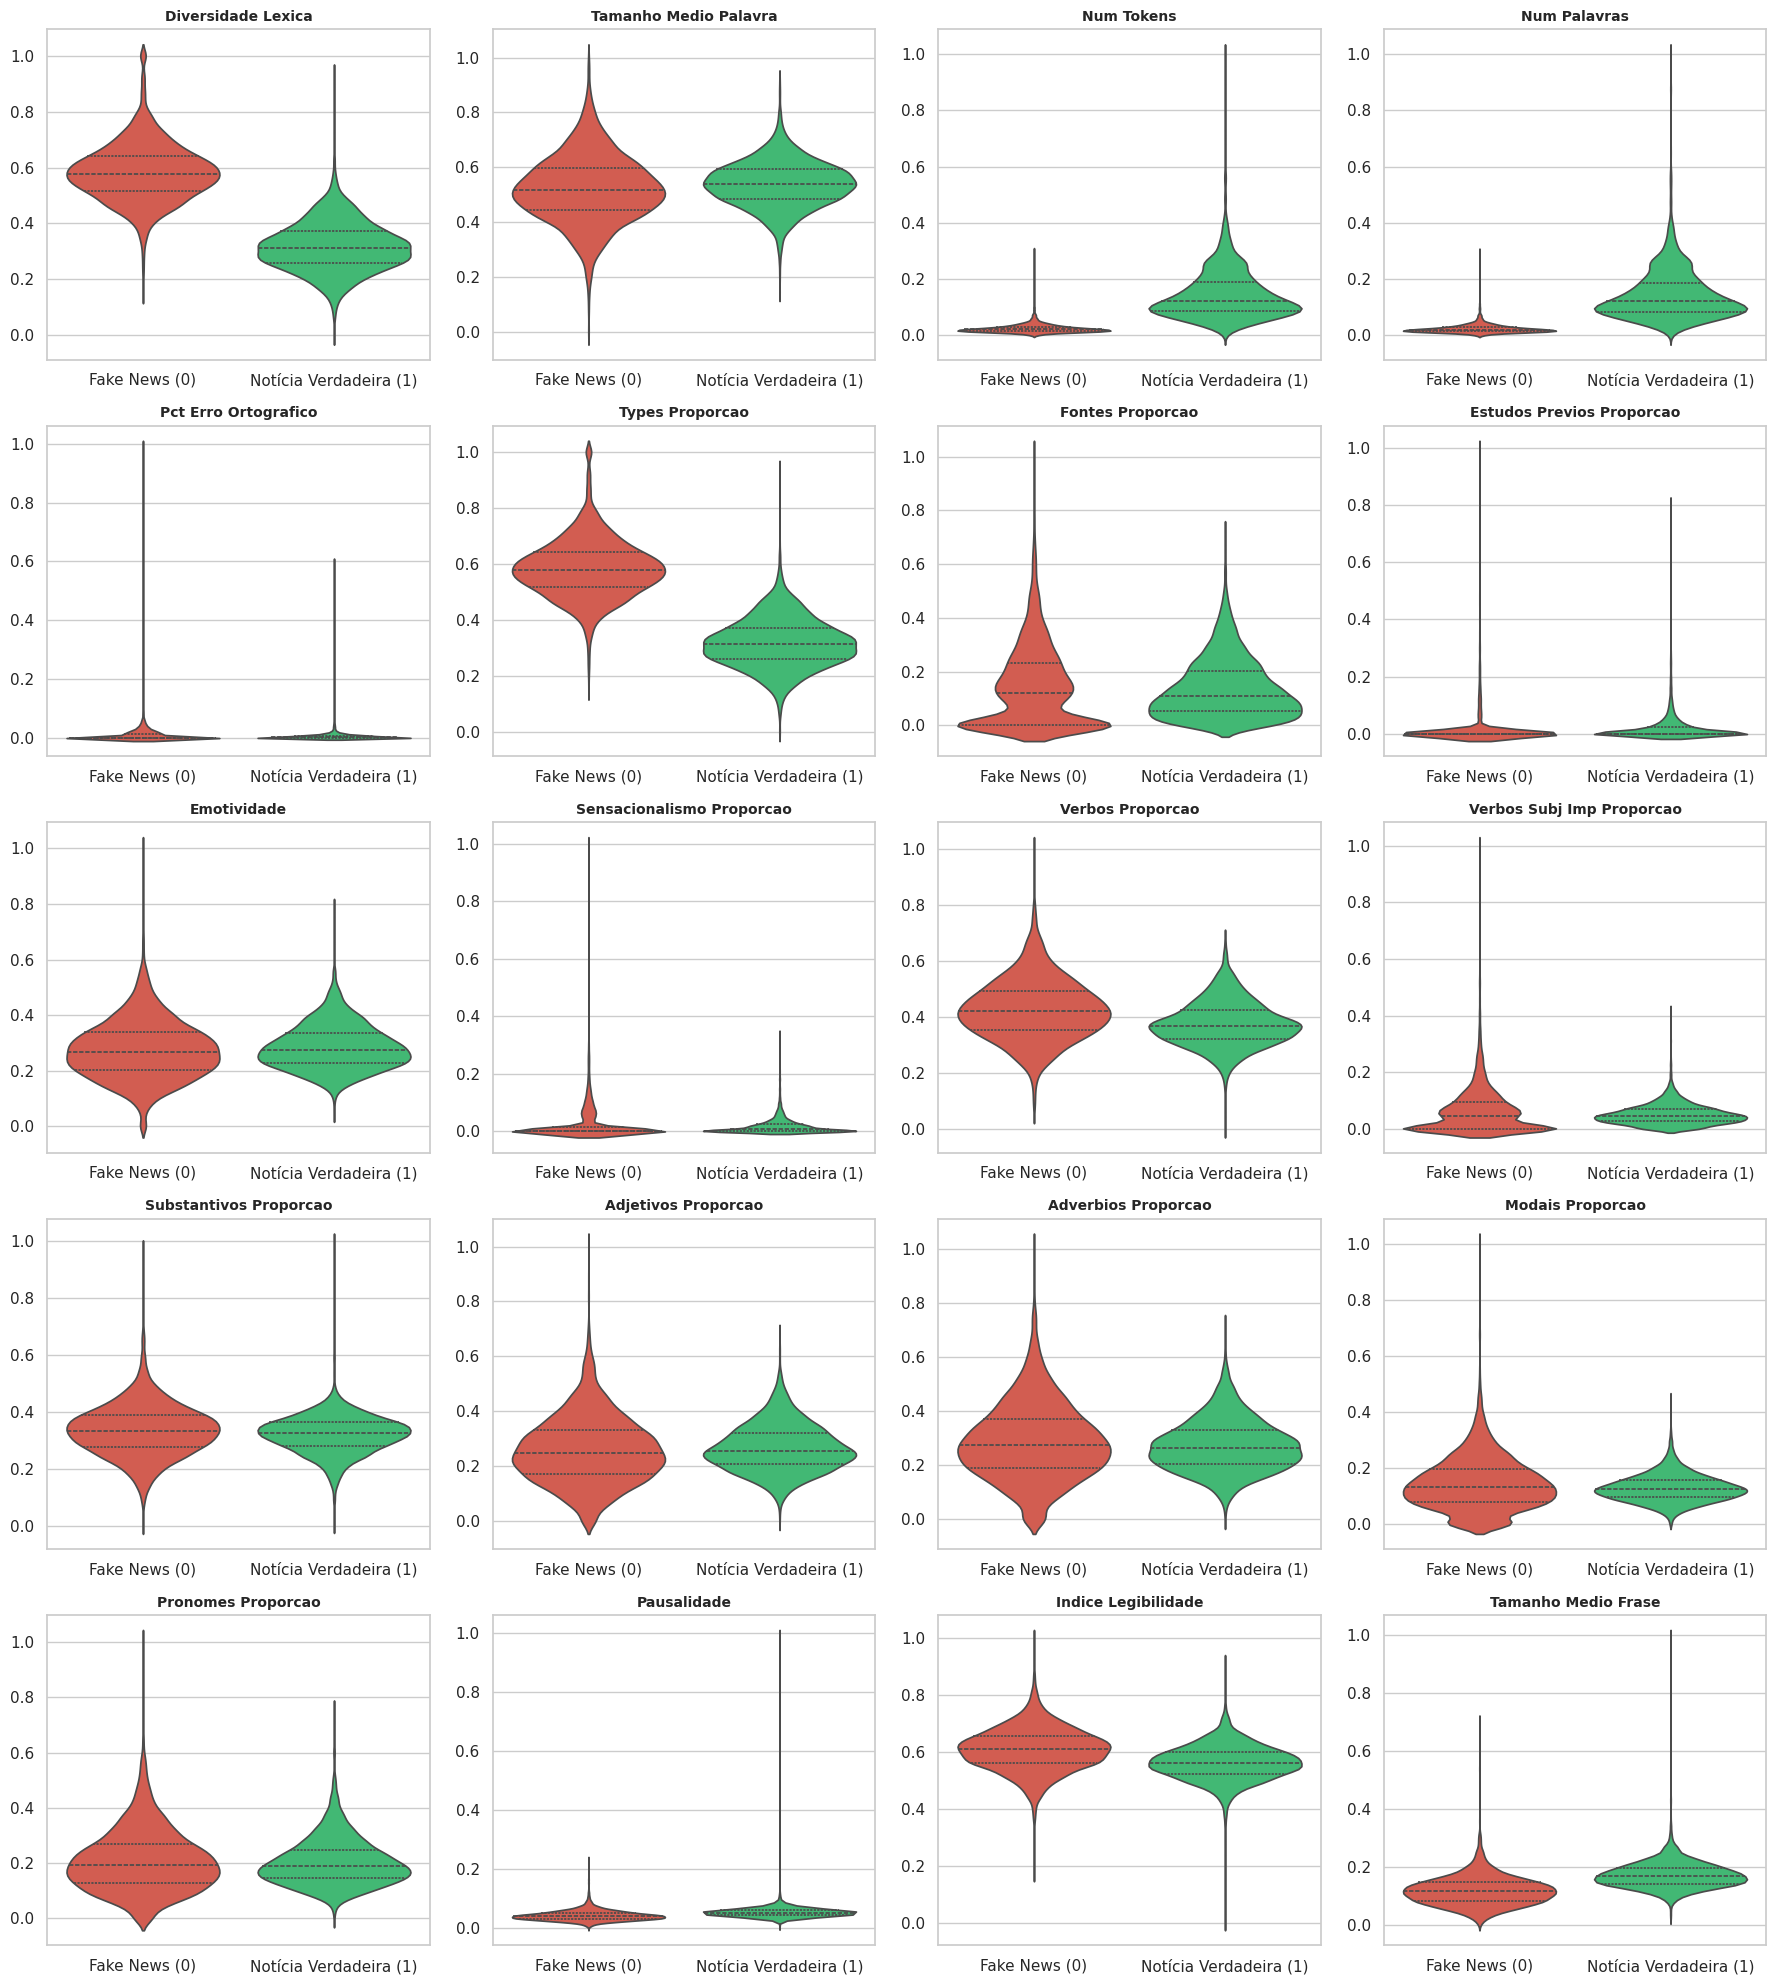

In [5]:
# Gráfico 3: Gráfico de Violino
n_cols = 4
n_rows = math.ceil(len(colunas_numericas) / n_cols)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 20))

idx = 0
for i in range(n_rows):
    for j in range(n_cols):
        if idx < len(colunas_numericas):
            var = colunas_numericas[idx]

            # Gerar Violin Plot com quartis
            sns.violinplot(
                data=df,
                x='tipo_noticia',
                y=var,
                hue='tipo_noticia',
                legend=False,
                ax=axes[i, j],
                palette=['#e74c3c', '#2ecc71'],
                inner='quartile',
            )

            axes[i, j].set_title(
                var.replace('_', ' ').title(), fontsize=10, fontweight='bold'
            )
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')
            idx += 1
        else:
            fig.delaxes(axes[i, j])  # Remove quadros vazios

plt.tight_layout()
plt.show()


## 5. Gráfico 4 — Matriz de gráficos de densidade (KDE)

O que esta célula faz:
- Para cada feature, plota a **densidade estimada (KDE)** dos valores, separada por `tipo_noticia` e sobreposta (`fill=True`, `common_norm=False` para comparar formas, não contagens absolutas).
- Complementa o violin plot: mostra onde as duas distribuições se sobrepõem e onde se separam, o que ajuda a avaliar visualmente o poder discriminativo de cada feature entre fake e verdadeira.
- Salva a figura em `matriz_densidade_kde.png`.

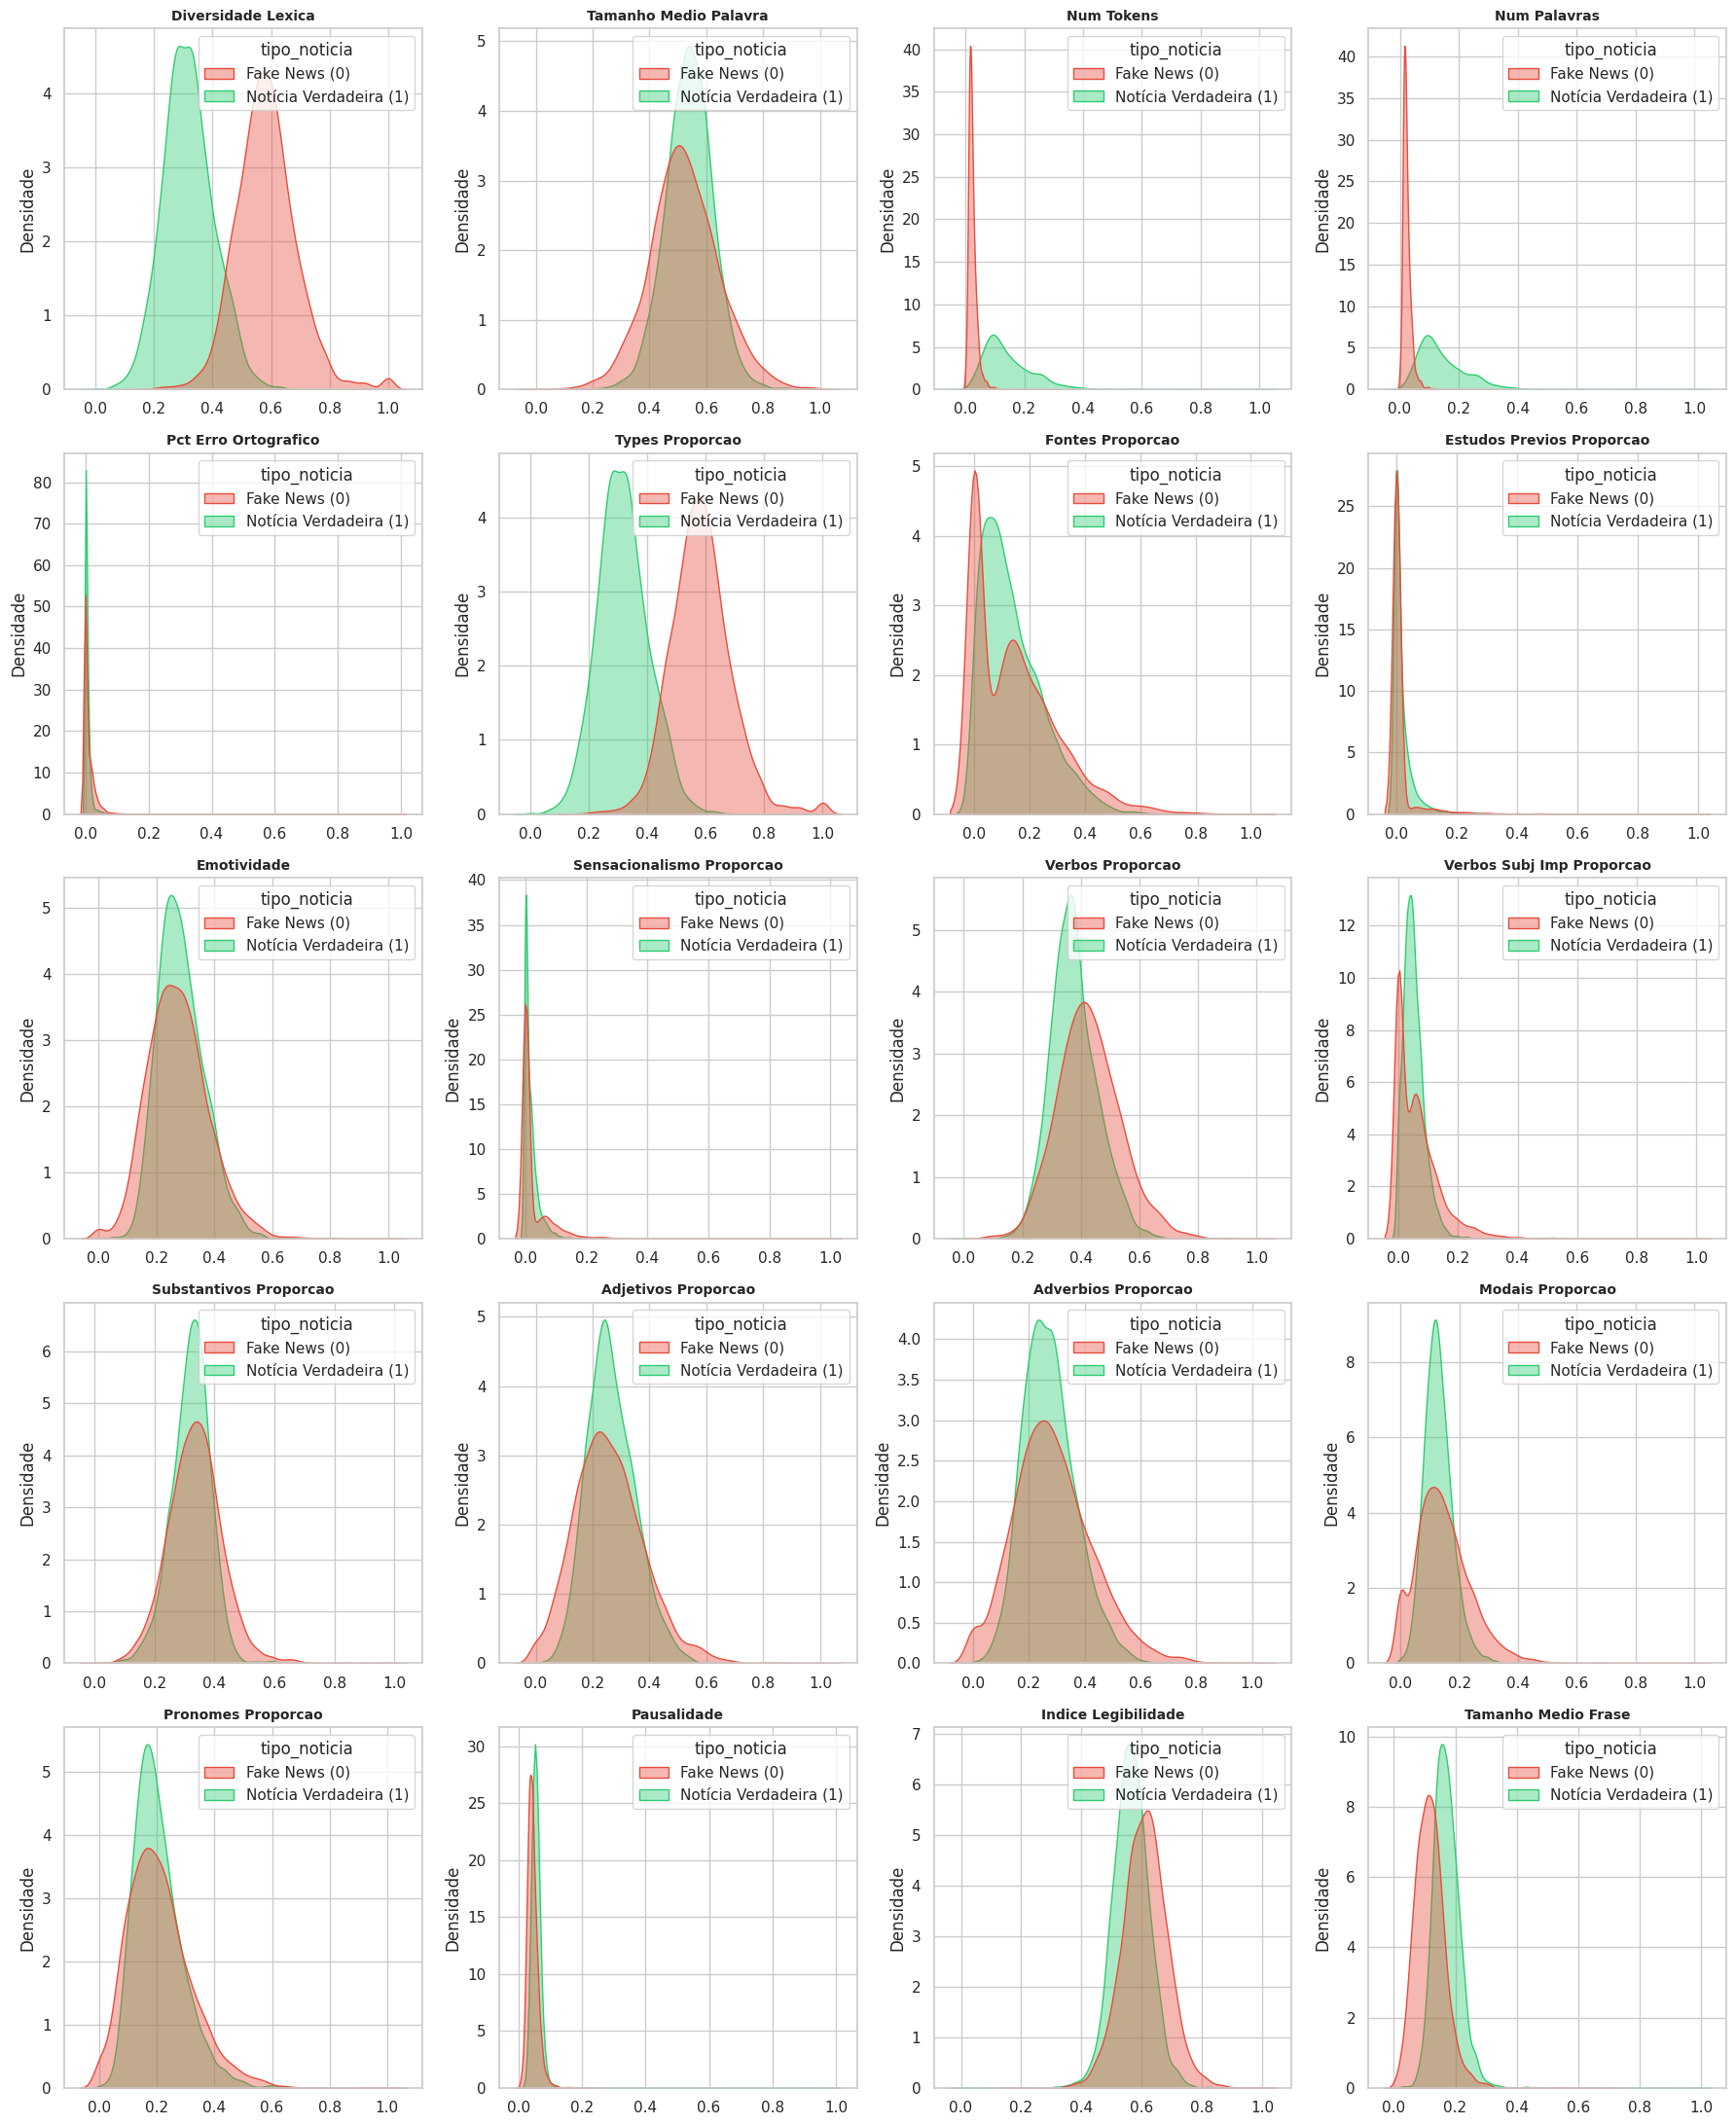

In [6]:
# Gráfico 4: Matriz de Gráficos de Densidade
n_cols = 4
n_rows = math.ceil(len(colunas_numericas) / n_cols)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 22))

idx = 0
for i in range(n_rows):
    for j in range(n_cols):
        if idx < len(colunas_numericas):
            var = colunas_numericas[idx]
            sns.kdeplot(
                data=df,
                x=var,
                hue='tipo_noticia',
                fill=True,
                common_norm=False,
                palette=['#e74c3c', '#2ecc71'],
                alpha=0.4,
                ax=axes[i, j]
            )
            axes[i, j].set_title(var.replace("_", " ").title(), fontsize=10, fontweight='bold')
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('Densidade')
            idx += 1
        else:
            fig.delaxes(axes[i, j])

plt.tight_layout()
plt.savefig('matriz_densidade_kde.png')
plt.show()


## 6. Gráfico 5 — Boxplots por feature (foco em outliers)

O que esta célula faz:
- Para cada feature, plota um **boxplot** por `tipo_noticia`, com `showfliers=False` (oculta outliers extremos no próprio gráfico, para não distorcer a escala) e grid tracejado leve para leitura.
- É o gráfico mais direto para "outliers por critério".

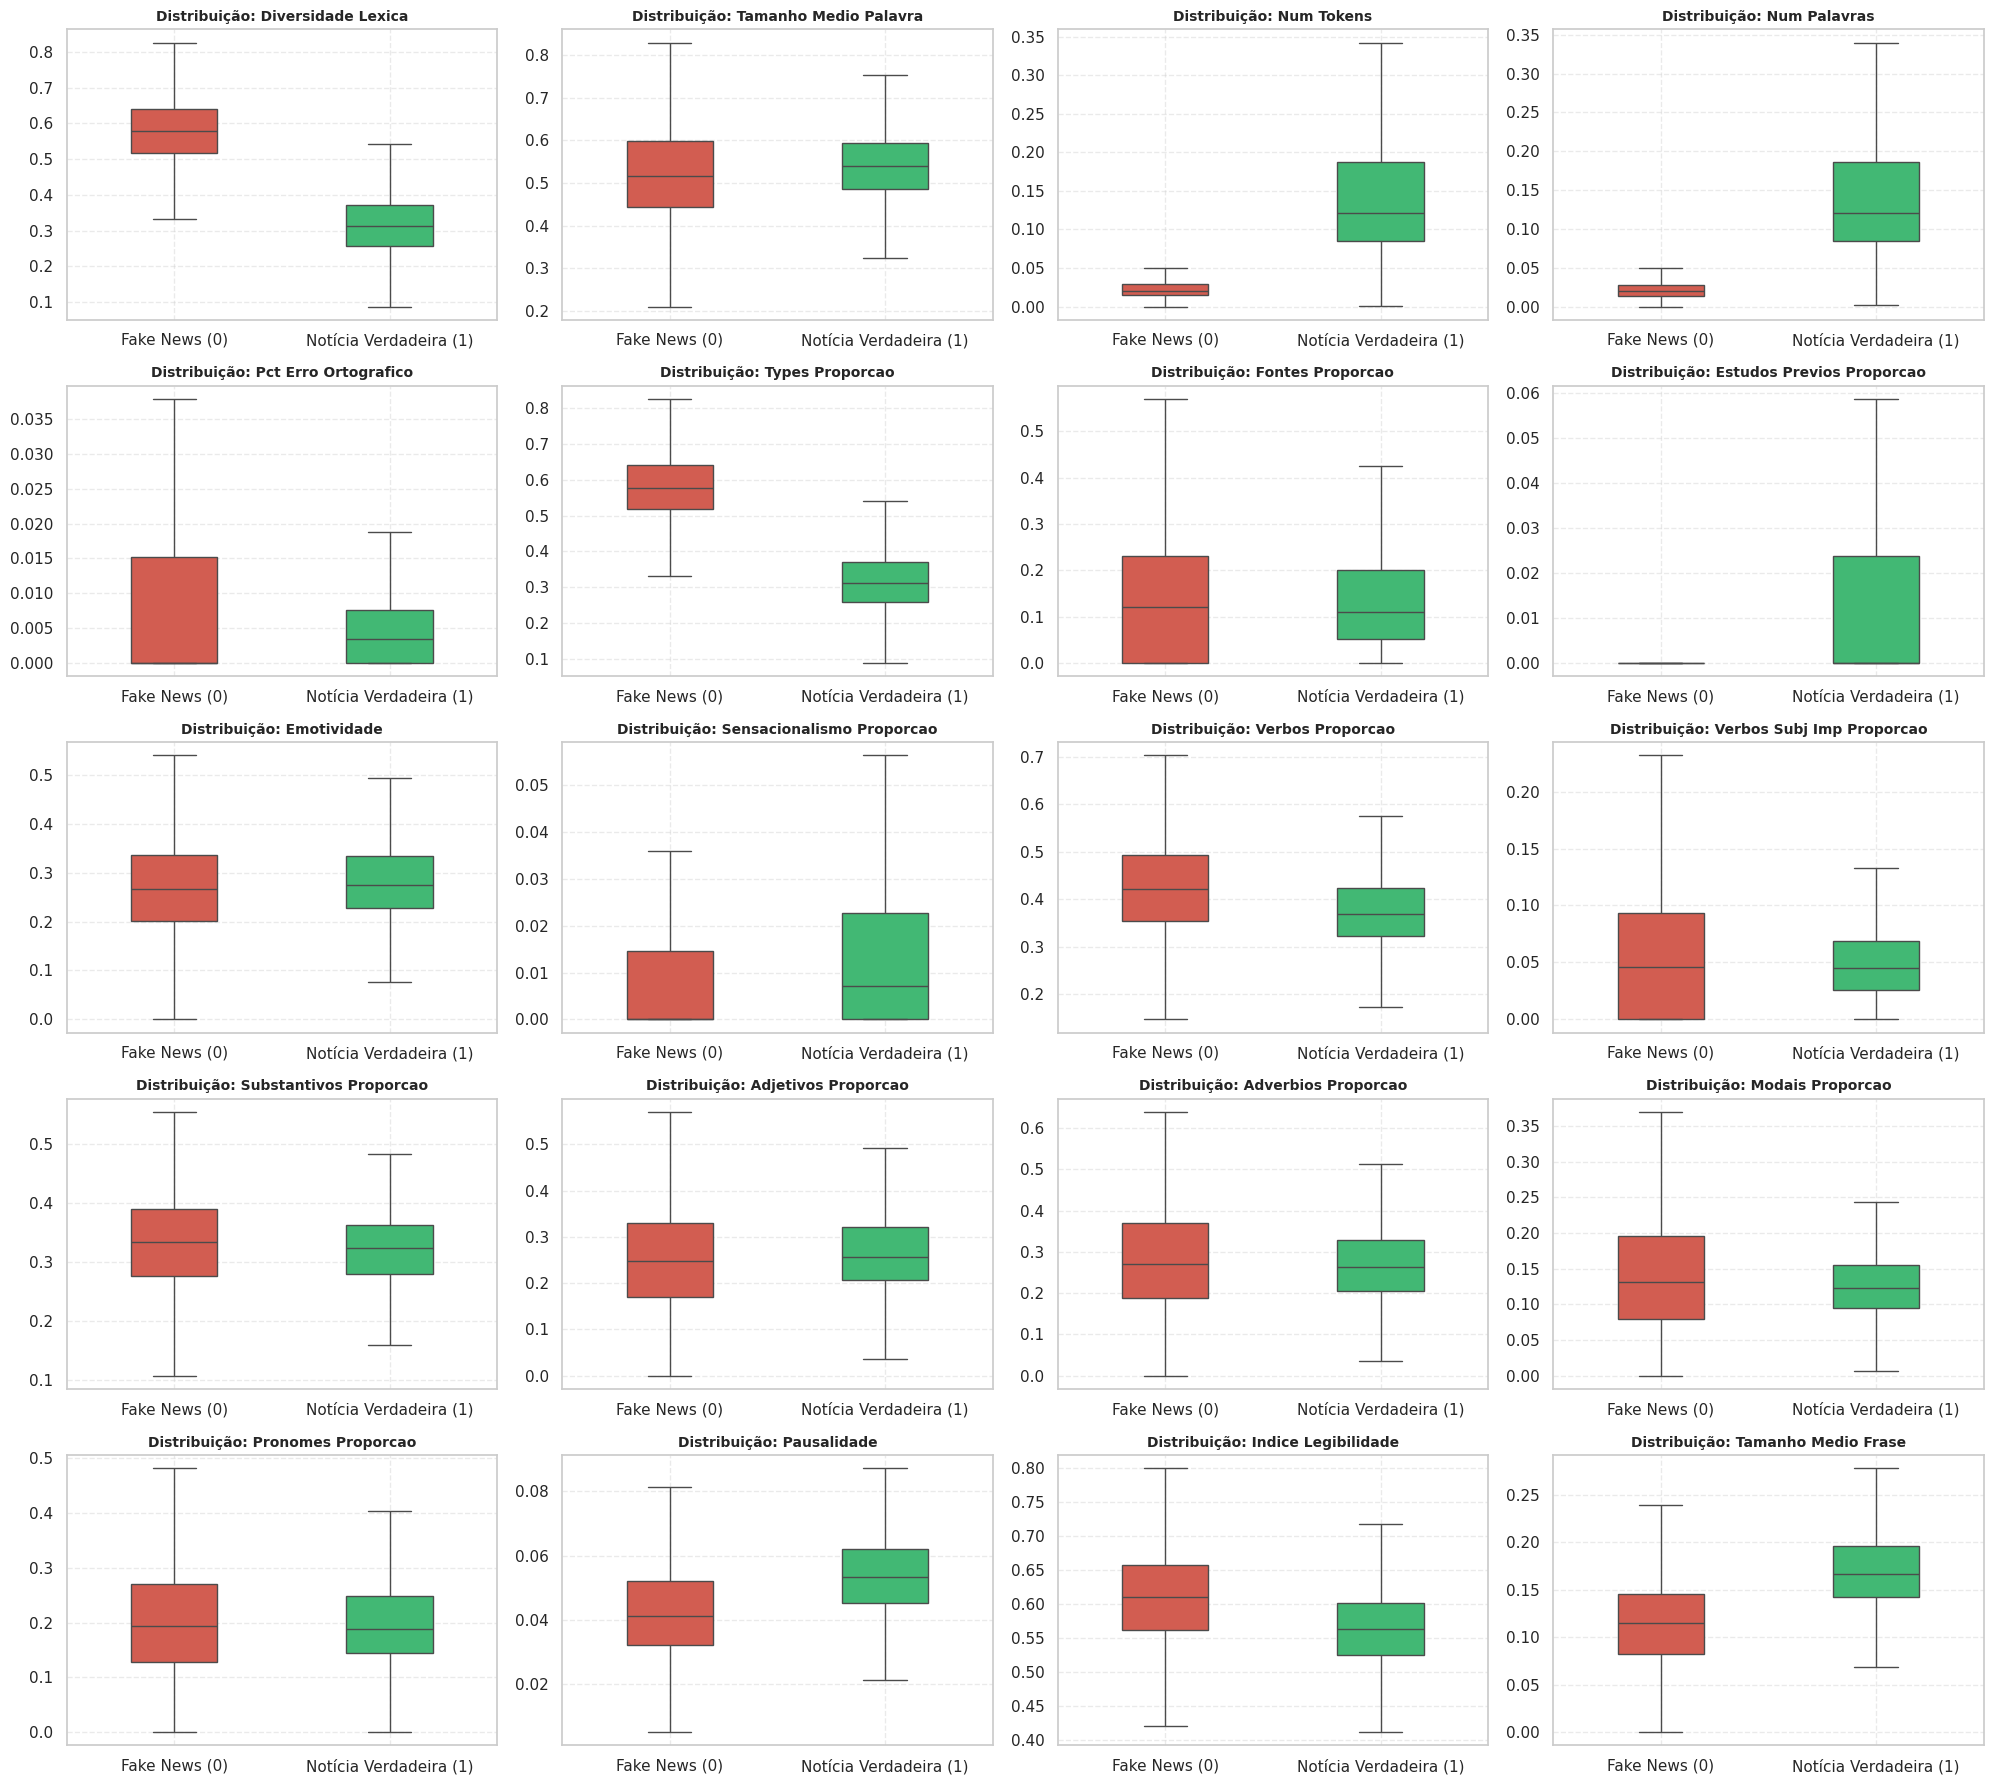

In [7]:
# Gráfico 5: Boxplot

sns.set_theme(style="whitegrid")

palette = {'Fake News (0)': '#e74c3c', 'Notícia Verdadeira (1)': '#2ecc71'}

n_cols = 4
n_rows = math.ceil(len(colunas_numericas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 18))
axes = axes.flatten()

for idx, col in enumerate(colunas_numericas):
    sns.boxplot(
        data=df,
        x='tipo_noticia',
        y=col,
        hue='tipo_noticia',
        palette=palette,
        legend=False,
        ax=axes[idx],
        showfliers=False,
        width=0.4,
    )

    axes[idx].set_title(
        f'Distribuição: {col.replace("_", " ").title()}',
        fontweight='bold',
        fontsize=10,
    )
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')
    axes[idx].grid(True, linestyle='--', alpha=0.4)

for i in range(len(colunas_numericas), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


## 7. Mapa de calor de correlação

O que esta célula faz:
- Calcula a matriz de correlação de Pearson entre todas as `colunas_numericas` e o `rotulo` (0/1), e plota como heatmap anotado (`sns.heatmap`), com escala de cor divergente (`coolwarm`) — vermelho para correlação positiva, azul para negativa.
- A linha/coluna `rotulo` mostra rapidamente quais features têm maior correlação linear (positiva ou negativa) com a classe, e o restante da matriz mostra colinearidade entre as próprias features (útil para identificar redundância entre criteria).

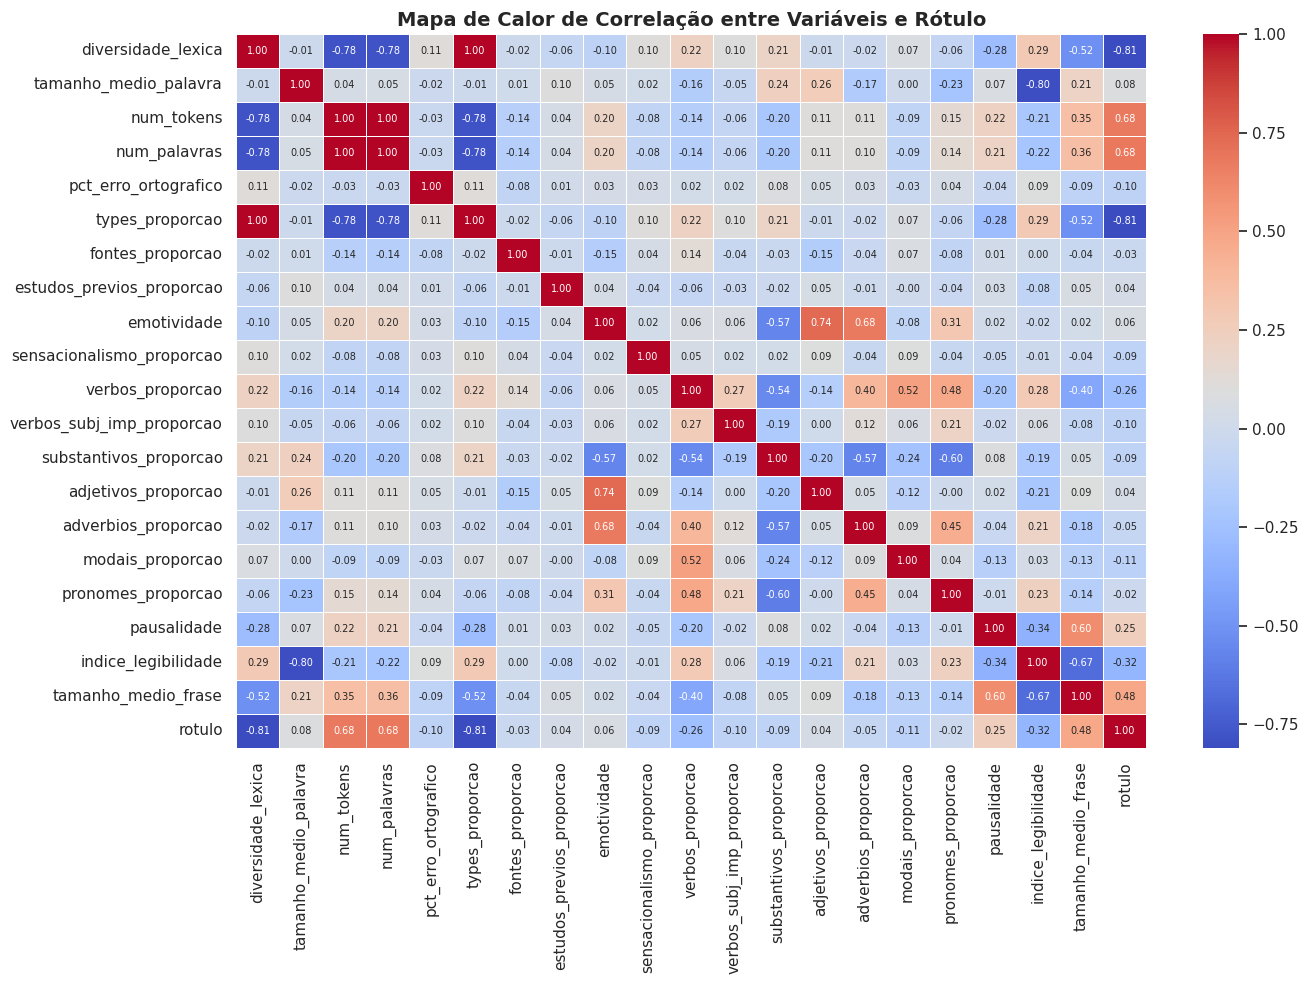

In [8]:
# Mapa de Calor de Correlação

# Selecionar variáveis numéricas + rótulo
cols_corr = colunas_numericas + ['rotulo']
corr = df[cols_corr].corr()

# Configuração do gráfico
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    cbar=True,
    linewidths=0.5,
    annot_kws={'size': 7},
)
plt.title(
    'Mapa de Calor de Correlação entre Variáveis e Rótulo',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.show()


## 8. Gráficos de dispersão para pares específicos de features

O que esta célula faz:
- Plota gráficos de dispersão (`scatter`) para 4 pares de features escolhidos manualmente em `PARES_DE_FEATURES` (ex.: `num_tokens` x `num_palavras`), coloridos por classe (fake/true), com o **coeficiente de correlação de Pearson** de cada par no título — útil para inspecionar visualmente relações que o heatmap só resume em um número.
- Salva a figura em `scatter_correlacoes.png`.

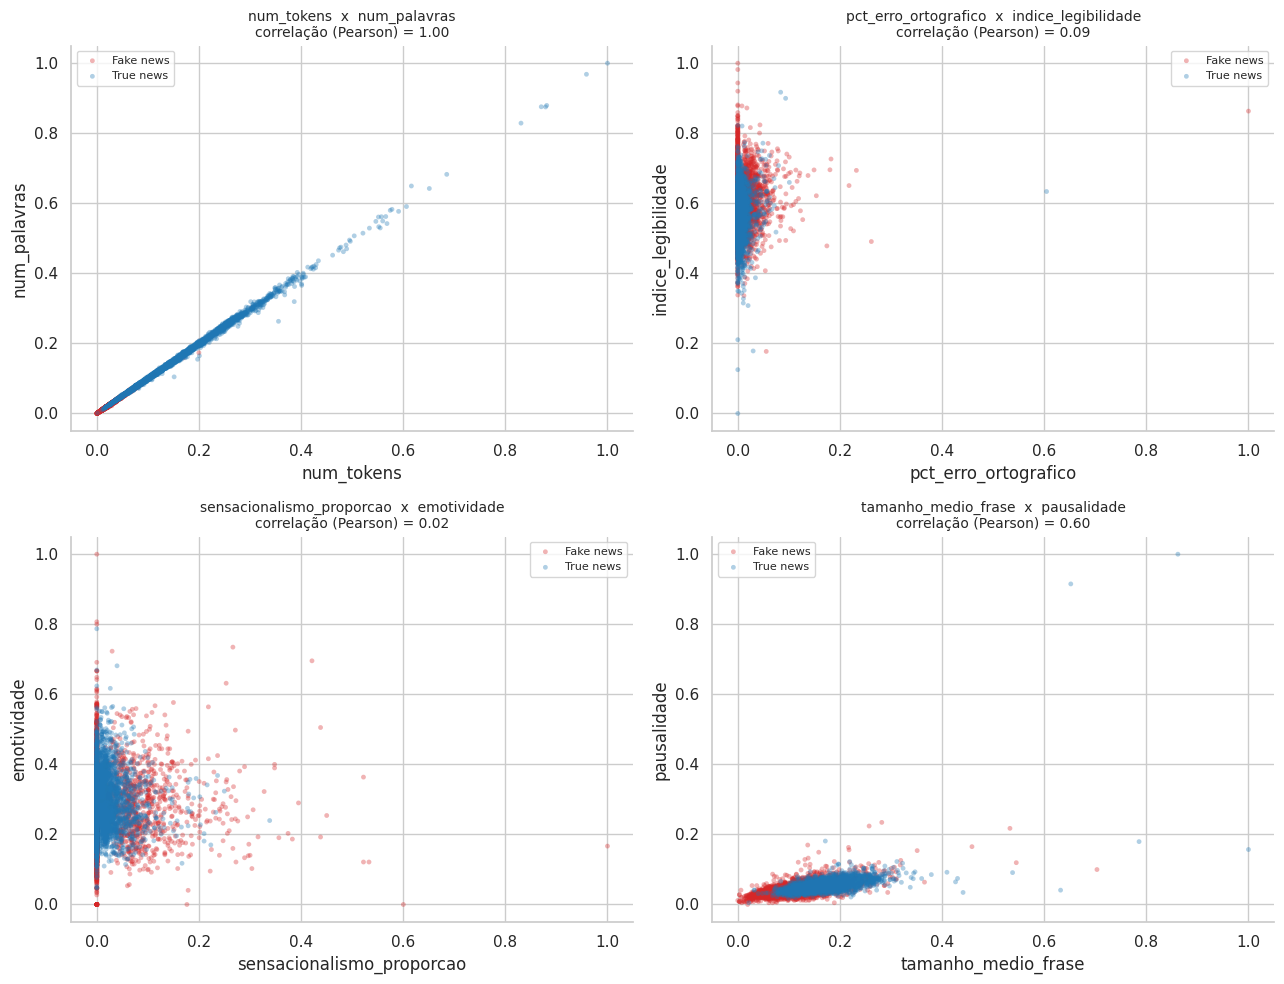

Gráficos salvos em: scatter_correlacoes.png


In [9]:
# Gráfico 6: Dispersão para pares específicos de features
#
# Gera gráficos de dispersão comparando pares de features numéricas do dataset
# DUAT, coloridos por rótulo (fake news x true news), com o coeficiente de
# correlação de Pearson no título de cada gráfico.
#
# Para escolher outros pares, edite a lista PARES_DE_FEATURES abaixo.

# Cada tupla é (feature_X, feature_Y). Adicione quantos pares quiser.
PARES_DE_FEATURES = [
    ("num_tokens", "num_palavras"),
    ("pct_erro_ortografico", "indice_legibilidade"),
    ("sensacionalismo_proporcao", "emotividade"),
    ("tamanho_medio_frase", "pausalidade"),
]

COL_ROTULO = "rotulo"
VALOR_FAKE = 0
VALOR_TRUE = 1

COR_FAKE = "#d62728"   # vermelho
COR_TRUE = "#1f77b4"   # azul
LABEL_FAKE = "Fake news"
LABEL_TRUE = "True news"

ARQUIVO_SAIDA = "scatter_correlacoes.png"


def plot_par(df: pd.DataFrame, x: str, y: str, ax: plt.Axes) -> None:
    """Plota um único par de features (X, Y) no eixo `ax`, separado por rótulo."""
    for valor, cor, label in (
        (VALOR_FAKE, COR_FAKE, LABEL_FAKE),
        (VALOR_TRUE, COR_TRUE, LABEL_TRUE),
    ):
        subset = df[df[COL_ROTULO] == valor]
        ax.scatter(
            subset[x], subset[y],
            c=cor, label=label,
            alpha=0.35, s=12, edgecolors="none",
        )

    corr = df[x].corr(df[y])
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{x}  x  {y}\ncorrelação (Pearson) = {corr:.2f}", fontsize=10)
    ax.legend(fontsize=8, loc="best")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


faltando = [c for par in PARES_DE_FEATURES for c in par if c not in df.columns]
if faltando:
    raise ValueError(f"Colunas não encontradas no dataset: {sorted(set(faltando))}")

n = len(PARES_DE_FEATURES)
cols = 2
rows = -(-n // cols)  # arredonda pra cima
fig, axes = plt.subplots(rows, cols, figsize=(6.5 * cols, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (x, y) in zip(axes, PARES_DE_FEATURES):
    plot_par(df, x, y, ax)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(ARQUIVO_SAIDA, dpi=150)
plt.show()
print(f"Gráficos salvos em: {ARQUIVO_SAIDA}")
